## Setup and Imports

In [2]:
# Install required packages
import subprocess
import sys

packages = ['torch', 'torchvision', 'einops']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import importlib

# Import custom model
import model
importlib.reload(model)
from model import (
    VisionTransformer,
    ViTSegmentation,
    create_vit_classifier,
    create_vit_segmentation,
    count_parameters
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print("Using CPU")

PyTorch version: 2.9.1+cpu
CUDA available: False
Using CPU


## 1. Test Vision Transformer for Classification

In [4]:
# Create ViT classifier for binary classification (tumor vs no tumor)
print("Creating ViT Classifier for Binary Classification")
print("="*60)

vit_binary = create_vit_classifier(
    num_classes=2,
    img_size=224,
    in_channels=3  # RGB images
)

print(f"Model: Vision Transformer")
print(f"Input size: 224x224x3")
print(f"Number of classes: 2 (tumor, no tumor)")
print(f"Patch size: 16x16")
print(f"Number of patches: {(224//16)**2}")
print(f"Embedding dimension: 768")
print(f"Transformer depth: 12 layers")
print(f"Number of attention heads: 12")
print(f"\nTotal parameters: {count_parameters(vit_binary):,}")

# Test forward pass
dummy_input = torch.randn(2, 3, 224, 224)  # Batch size 2
output = vit_binary(dummy_input)
print(f"\nOutput shape: {output.shape}")
print(f"Expected: (batch_size=2, num_classes=2)")

Creating ViT Classifier for Binary Classification
Model: Vision Transformer
Input size: 224x224x3
Number of classes: 2 (tumor, no tumor)
Patch size: 16x16
Number of patches: 196
Embedding dimension: 768
Transformer depth: 12 layers
Number of attention heads: 12

Total parameters: 85,800,194
Model: Vision Transformer
Input size: 224x224x3
Number of classes: 2 (tumor, no tumor)
Patch size: 16x16
Number of patches: 196
Embedding dimension: 768
Transformer depth: 12 layers
Number of attention heads: 12

Total parameters: 85,800,194

Output shape: torch.Size([2, 2])
Expected: (batch_size=2, num_classes=2)

Output shape: torch.Size([2, 2])
Expected: (batch_size=2, num_classes=2)


In [5]:
# Create ViT classifier for multi-class classification
print("Creating ViT Classifier for Multi-Class Classification")
print("="*60)

vit_multiclass = create_vit_classifier(
    num_classes=4,  # glioma, healthy, meningioma, pituitary
    img_size=224,
    in_channels=3
)

print(f"Model: Vision Transformer")
print(f"Number of classes: 4 (glioma, healthy, meningioma, pituitary)")
print(f"Total parameters: {count_parameters(vit_multiclass):,}")

# Test forward pass
dummy_input = torch.randn(4, 3, 224, 224)
output = vit_multiclass(dummy_input)
print(f"\nOutput shape: {output.shape}")
print(f"Expected: (batch_size=4, num_classes=4)")

# Show predicted probabilities
probs = torch.softmax(output, dim=1)
print(f"\nSample predictions (probabilities):")
print(probs[0].detach().numpy())

Creating ViT Classifier for Multi-Class Classification
Model: Vision Transformer
Number of classes: 4 (glioma, healthy, meningioma, pituitary)
Total parameters: 85,801,732
Model: Vision Transformer
Number of classes: 4 (glioma, healthy, meningioma, pituitary)
Total parameters: 85,801,732

Output shape: torch.Size([4, 4])
Expected: (batch_size=4, num_classes=4)

Sample predictions (probabilities):

Output shape: torch.Size([4, 4])
Expected: (batch_size=4, num_classes=4)

Sample predictions (probabilities):
[0.4952998  0.14367126 0.294017   0.067012  ]
[0.4952998  0.14367126 0.294017   0.067012  ]


## 2. Test Vision Transformer for Segmentation

In [6]:
# Create ViT segmentation model for multi-modal MRI
print("Creating ViT Segmentation Model")
print("="*60)

vit_seg = create_vit_segmentation(
    num_classes=4,  # Background, Whole Tumor, Tumor Core, Enhancing Tumor
    img_size=224,
    in_channels=4  # Multi-modal: T1, T2, FLAIR, T1-CE
)

print(f"Model: Vision Transformer for Segmentation")
print(f"Input size: 224x224x4 (multi-modal MRI)")
print(f"Input channels: T1, T2, FLAIR, T1-CE")
print(f"Segmentation classes: 4")
print(f"  - Background")
print(f"  - Whole Tumor")
print(f"  - Tumor Core")
print(f"  - Enhancing Tumor")
print(f"\nTotal parameters: {count_parameters(vit_seg):,}")

# Test forward pass
dummy_input = torch.randn(2, 4, 224, 224)  # Batch size 2, 4 modalities
output = vit_seg(dummy_input)
print(f"\nOutput shape: {output.shape}")
print(f"Expected: (batch_size=2, num_classes=4, height=224, width=224)")

Creating ViT Segmentation Model
Model: Vision Transformer for Segmentation
Input size: 224x224x4 (multi-modal MRI)
Input channels: T1, T2, FLAIR, T1-CE
Segmentation classes: 4
  - Background
  - Whole Tumor
  - Tumor Core
  - Enhancing Tumor

Total parameters: 91,084,100
Model: Vision Transformer for Segmentation
Input size: 224x224x4 (multi-modal MRI)
Input channels: T1, T2, FLAIR, T1-CE
Segmentation classes: 4
  - Background
  - Whole Tumor
  - Tumor Core
  - Enhancing Tumor

Total parameters: 91,084,100

Output shape: torch.Size([2, 4, 224, 224])
Expected: (batch_size=2, num_classes=4, height=224, width=224)

Output shape: torch.Size([2, 4, 224, 224])
Expected: (batch_size=2, num_classes=4, height=224, width=224)


## 3. Visualize Model Architecture

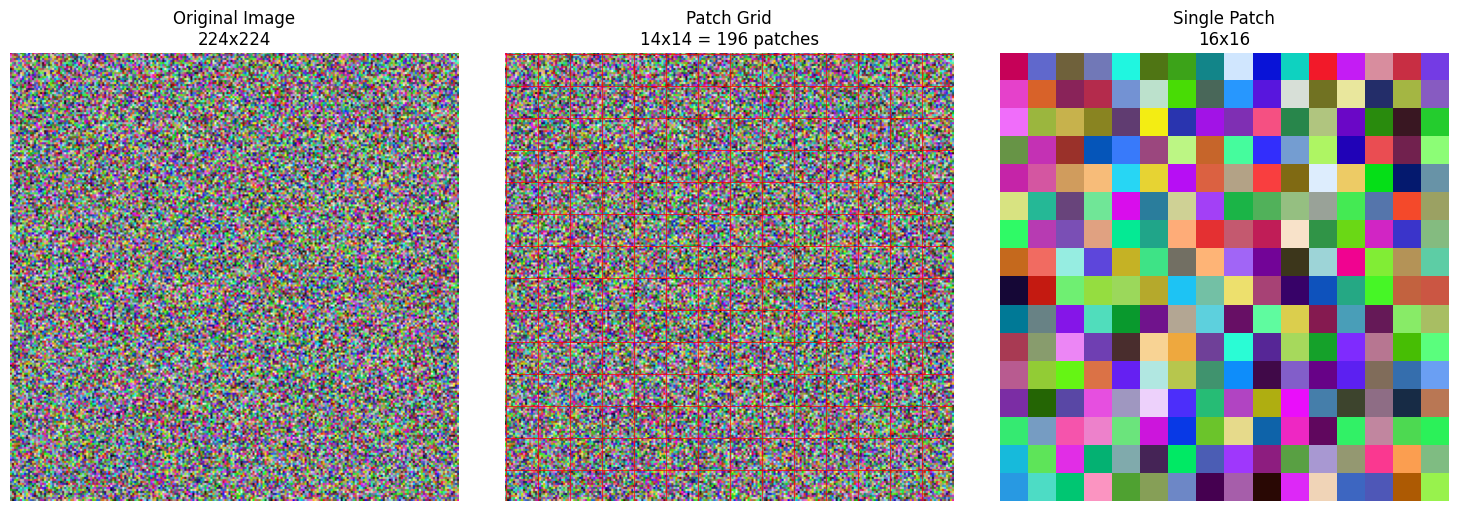


ViT Architecture Overview:
  1. Image → Patches: 196 patches of 16x16
  2. Patch Embedding: Each patch → 768-dim vector
  3. Add [CLS] token and positional embeddings
  4. Transformer Encoder: 12 layers of self-attention
  5. Classification: Use [CLS] token → Linear → Output


In [7]:
# Visualize patch embedding process
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
img_size = 224
patch_size = 16
num_patches = (img_size // patch_size) ** 2

# Create dummy image
dummy_img = np.random.rand(img_size, img_size, 3)

axes[0].imshow(dummy_img)
axes[0].set_title('Original Image\n224x224')
axes[0].axis('off')

# Show patch grid
axes[1].imshow(dummy_img)
for i in range(0, img_size, patch_size):
    axes[1].axhline(i, color='red', linewidth=0.5)
    axes[1].axvline(i, color='red', linewidth=0.5)
axes[1].set_title(f'Patch Grid\n{img_size//patch_size}x{img_size//patch_size} = {num_patches} patches')
axes[1].axis('off')

# Show single patch
single_patch = dummy_img[:patch_size, :patch_size, :]
axes[2].imshow(single_patch)
axes[2].set_title(f'Single Patch\n{patch_size}x{patch_size}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nViT Architecture Overview:")
print(f"  1. Image → Patches: {num_patches} patches of {patch_size}x{patch_size}")
print(f"  2. Patch Embedding: Each patch → 768-dim vector")
print(f"  3. Add [CLS] token and positional embeddings")
print(f"  4. Transformer Encoder: 12 layers of self-attention")
print(f"  5. Classification: Use [CLS] token → Linear → Output")

## 4. Model Summary and Comparison

In [8]:
import pandas as pd

# Create comparison table
models_info = [
    {
        'Model': 'ViT Binary Classification',
        'Input Shape': '(B, 3, 224, 224)',
        'Output Shape': '(B, 2)',
        'Parameters': f"{count_parameters(vit_binary):,}",
        'Use Case': 'Tumor vs No Tumor'
    },
    {
        'Model': 'ViT Multi-Class Classification',
        'Input Shape': '(B, 3, 224, 224)',
        'Output Shape': '(B, 4)',
        'Parameters': f"{count_parameters(vit_multiclass):,}",
        'Use Case': '4 tumor types'
    },
    {
        'Model': 'ViT Segmentation',
        'Input Shape': '(B, 4, 224, 224)',
        'Output Shape': '(B, 4, 224, 224)',
        'Parameters': f"{count_parameters(vit_seg):,}",
        'Use Case': 'Multi-modal segmentation'
    }
]

df = pd.DataFrame(models_info)
print("\nModel Comparison:")
print("="*80)
print(df.to_string(index=False))
print("\nNote: B = Batch size")


Model Comparison:
                         Model      Input Shape     Output Shape Parameters                 Use Case
     ViT Binary Classification (B, 3, 224, 224)           (B, 2) 85,800,194        Tumor vs No Tumor
ViT Multi-Class Classification (B, 3, 224, 224)           (B, 4) 85,801,732            4 tumor types
              ViT Segmentation (B, 4, 224, 224) (B, 4, 224, 224) 91,084,100 Multi-modal segmentation

Note: B = Batch size


## 5. Test with Real Image

In [9]:
# Load a sample preprocessed image
from preprocessing import zscore_normalize

# Find a sample image from preprocessed data
preprocessed_dir = Path("Dataset/preprocessed_data/train")
sample_images = list(preprocessed_dir.rglob('*.jpg'))[:3]

if len(sample_images) > 0:
    print(f"Testing ViT with {len(sample_images)} real images")
    print("="*60)
    
    # Prepare batch
    batch_images = []
    
    for img_path in sample_images:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        img_array = np.array(img)
        
        # Normalize
        img_normalized = zscore_normalize(img_array, per_channel=True)
        
        # Convert to tensor (C, H, W)
        img_tensor = torch.from_numpy(img_normalized).permute(2, 0, 1).float()
        batch_images.append(img_tensor)
    
    # Create batch
    batch = torch.stack(batch_images)
    print(f"Batch shape: {batch.shape}")
    
    # Forward pass through ViT
    vit_multiclass.eval()
    with torch.no_grad():
        outputs = vit_multiclass(batch)
        probs = torch.softmax(outputs, dim=1)
    
    print(f"\nPredictions:")
    class_names = ['glioma', 'healthy', 'meningioma', 'pituitary']
    
    for i, (img_path, prob) in enumerate(zip(sample_images, probs)):
        pred_class = torch.argmax(prob).item()
        confidence = prob[pred_class].item()
        print(f"\nImage {i+1}: {img_path.name}")
        print(f"  Predicted: {class_names[pred_class]} (confidence: {confidence:.2%})")
        print(f"  All probabilities: {prob.numpy()}")
    
    print("\n✓ ViT successfully processed real images!")
else:
    print("No preprocessed images found. Run preprocessing first.")

Testing ViT with 3 real images
Batch shape: torch.Size([3, 3, 224, 224])
Batch shape: torch.Size([3, 3, 224, 224])

Predictions:

Image 1: MR0001 (10).jpg
  Predicted: glioma (confidence: 47.90%)
  All probabilities: [0.47904736 0.14338787 0.2337884  0.14377634]

Image 2: MR0001 (12).jpg
  Predicted: glioma (confidence: 56.80%)
  All probabilities: [0.5679678  0.11531866 0.20916748 0.10754616]

Image 3: MR0001 (2).jpg
  Predicted: glioma (confidence: 50.22%)
  All probabilities: [0.5021926  0.12728141 0.22733757 0.14318843]

✓ ViT successfully processed real images!

Predictions:

Image 1: MR0001 (10).jpg
  Predicted: glioma (confidence: 47.90%)
  All probabilities: [0.47904736 0.14338787 0.2337884  0.14377634]

Image 2: MR0001 (12).jpg
  Predicted: glioma (confidence: 56.80%)
  All probabilities: [0.5679678  0.11531866 0.20916748 0.10754616]

Image 3: MR0001 (2).jpg
  Predicted: glioma (confidence: 50.22%)
  All probabilities: [0.5021926  0.12728141 0.22733757 0.14318843]

✓ ViT succe